# Leveraging Reinforcement Learning to Solve the Portfolio Selection Problem

#### **Author:** [Albina Mulikova](mailto:albina.mulikova@st.ovgu.de)

<p style='text-align: justify;'> Code below is provided to support master's thesis study that allows to implement the Reinforcement Learning for determining best performing portfolio by allocating optimal weights among a set of preselected ETFs. </p>
<p style='text-align: justify;'> The following code was based on initially proposed RL model by Hariom Tatsat et al. (2020) which was implemented for solving Porfolio optimization for cryptocurrencies represented as DQN-based RL approach with the optimal solution given as a policy. Standardized working environment was set in accordance with OpenAI Gym open source Python library to facilitate the training, moreover, the modification of the RL Agent and RL Environment was made using work of Derek Snow (2019).
</p>
<p style='text-align: justify;'> The Benchmark portfolio is built following "Buy and Hold" policy, where initial investment is equally distributed among assets at first timestep and kept until the termination point.Testing performance is made on two test datasets: including and excluding COVID period. The intention behind subdivision of testing dataset is to understand the ability and extent of the RL model to react to unexpected "Black Swan" events. The model learns over the period of time, develops a policy, the the process of exploitation starts. The results of the model evaluation on the testing set showed an overall profit in the pre-COVID period and overall decreasing volatility over the whole period of testing.</p>

### Content

* [1. Problem Description](#0) 
* [2. Load python packages and data](#1) 
    * [2.1. Load libraries](#1.1)   
    * [2.2. Data import and data cleaning](#1.2)  
* [3. Exploratory Data Analysis(EDA)](#2) 
    * [3.1 Descriptive Statistics](#2.1)    
    * [3.2. Data Visualisation](#2.2)
    * [3.3. Data Storage](#2.3)
* [4. Designing RL Model](#3)      
    * [4.1. Creating RL environment](#3.1) 
    * [4.2. Agent Script](#3.2)
    * [4.3. Model Training](#3.3)        
* [5.Testing the Model](#4)    
    * [5.2. Testing excluding COVID Period](#4.1) 
    * [5.2. Testing including COVID Period](#4.2)




<a id='0'></a>
### 1. Problem Description

<p style='text-align: justify;'>Portfolio Selection Problem is defined by the strategy of investing into subset of assets under constraint of minimizing the risk simultaneously maximizing the portfolio return. Typically, gaining the profit is ensured by the dynamic allocation of capital among selected assets at initial stage and consequent rebalancing in the process. Due to the real-world uncertainties, the actual return of each security cannot be forecasted precisely. Consequently, the efficient strategy of selecting optimized distribution of weights among portfolio assets is the key problem for investors in order to generate plans offering the lowest risk and the highest possible expected return for clients.  </p>

<p style='text-align: justify;'> Since portfolio management process can be regarded as Markov Decision Process (MDP), the Reinforcement Learning (RL) approach can be applied for optimizing asset allocation. The RL modeling requires the design of the four main elements of the RL Agent, such as environment, action and reward/ penalty, as well as the creation of RL framework itself. The finite set of financial assets is chosen and the RL Agent is to construct model mimicking the market aiming to maximize return while determining the policy for allocating the finite budget of funds to those assets optimally. The RL Agent is to be trained on real market data and effectiveness of applied model is then to be tested on out-of-sample dataset and compared to performance of standard "Buy-and-Hold" portfolio strategy.   </p>

<a id='1'></a>
### 2. Load python packages and data

<a id='1.1'></a>
#### 2.1. Load libraries

In [11]:
!pip install --upgrade pip
!pip install --upgrade tensorflow
!pip install --upgrade yfinance

In [29]:
import yfinance as yf
import numpy as np
from numpy.linalg import inv,pinv
import pandas as pd
from pandas import set_option
from pandas.plotting import scatter_matrix
pd.options.display.float_format = '{:.4f}'.format
from pandas_datareader import DataReader
import matplotlib.pyplot as plt
plt.style.use("seaborn")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
import seaborn as sns
import datetime
import math
from numpy.random import choice
import random
from collections import deque
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from keras.layers import Input, Dense, Flatten, Dropout
from keras.models import Model
from keras.models import load_model
from keras.regularizers import l2
from IPython.core.debugger import set_trace
import riskfolio as rp
import riskfolio.PlotFunctions as plf
import warnings
warnings.filterwarnings('ignore')

<a id='1.2'></a>
#### 2.2. Data import and data cleaning

In [30]:
etfs = ['BNDX','EMB','MUB','VAW','VEA','VHT','VWO','EFA','EEM','VGIT']

In [31]:
spdr = ['SPY']

In [32]:
# Time period:

# Train dataset
trainstartdate = '2014-01-01'
trainenddate   = '2018-12-31'

# Test dataset excluding COVID period
teststartdate1 = '2019-01-01'
trainenddate1   = '2019-12-31'

# Test dataset including COVID period
trainstartdate2 = '2019-01-01'
trainenddate2   = '2021-09-30'

In [33]:
traindataset = yf.download(etfs, start = trainstartdate, end = trainenddate)
traindataset = traindataset.loc[:,('Adj Close', slice(None))]
traindataset.columns = etfs

[*********************100%***********************]  10 of 10 completed


In [34]:
testdataset1 = yf.download(etfs, start = teststartdate1, end = trainenddate1 )
testdataset1 = testdataset1.loc[:,('Adj Close', slice(None))]
testdataset1.columns = etfs

[*********************100%***********************]  10 of 10 completed


In [35]:
testdataset2 = yf.download(etfs, start = trainstartdate2, end = trainenddate2)
testdataset2 = testdataset2.loc[:,('Adj Close', slice(None))]
testdataset2.columns = etfs

[*********************100%***********************]  10 of 10 completed


In [8]:
spdr_data1 = yf.download(spdr, start = trainstartdate, end = trainenddate)
spdr_data1.drop(['Open','High','Low','Close','Volume'], axis=1, inplace=True)
spdr_data1.columns = ['S&P500']

[*********************100%***********************]  1 of 1 completed


In [9]:
spdr_data2 = yf.download(spdr, start = teststartdate1, end = trainenddate1)
spdr_data2.drop(['Open','High','Low','Close','Volume'], axis=1, inplace=True)
spdr_data2.columns = ['S&P500']

[*********************100%***********************]  1 of 1 completed


In [10]:
spdr_data3 = yf.download(spdr, start = trainstartdate2, end = trainenddate2)
spdr_data3.drop(['Open','High','Low','Close','Volume'], axis=1, inplace=True)
spdr_data3.columns = ['S&P500']

[*********************100%***********************]  1 of 1 completed


<a id='2'></a>
### 3. Exploratory Data Analysis(EDA)

<a id='2.1'></a>
#### 3.1. Descriptive Statistics

In [11]:
print('Null Values =', traindataset.isnull().values.any())

Null Values = False


In case there are null values, the the missing values will be filled with the last value available in the dataset. 

In [ ]:
# Fill the missing values with the last available value in the dataset. 
traindataset=traindataset.fillna(method='ffill')
traindataset.head()

In [12]:
traindataset.shape

(1258, 10)

In [13]:
traindataset.head()

,BNDX,EMB,MUB,VAW,VEA,VHT,VWO,EFA,EEM,VGIT
Date,,,,,,,,,,
2013-12-31,42.5523,35.8164,54.0118,76.0670,86.6381,90.7499,33.3072,54.6101,91.7382,33.5276
2014-01-02,42.5695,34.4369,53.0539,76.0810,86.9137,90.0555,32.7478,54.7496,91.2664,32.3541
2014-01-03,42.5351,34.3769,53.1103,76.1513,86.9220,89.9500,32.7558,54.7496,91.4751,32.3133
2014-01-06,42.6381,34.0513,53.0459,76.4537,86.9721,89.3963,32.6918,54.8106,91.1031,32.0036
2014-01-07,42.7410,34.1969,53.3437,76.5522,87.1224,89.3611,32.8836,54.8978,92.1647,32.1340


In [25]:
traindataset.tail()

,BNDX,EMB,MUB,VAW,VEA,VHT,VWO,EFA,EEM,VGIT
Date,,,,,,,,,,
2018-12-21,51.3248,36.6717,53.6748,91.9796,102.5526,101.2773,33.7121,59.7277,146.4778,35.0125
2018-12-24,51.4617,36.3290,53.0500,91.9349,102.7224,98.7342,33.3437,59.8956,143.2799,34.7416
2018-12-26,51.4142,37.0525,54.2809,92.0690,102.4865,103.0992,34.1903,59.6679,149.9150,35.3560
2018-12-27,51.4427,37.0049,54.4394,92.4531,102.7035,104.8452,34.2182,59.8577,151.3128,35.2815
2018-12-28,51.4807,37.3572,54.7285,92.5157,102.7790,104.2284,34.4415,60.0760,151.5138,35.5329


In [107]:
testdataset2.tail()

,BNDX,EMB,MUB,VAW,VEA,VHT,VWO,EFA,EEM,VGIT
Date,,,,,,,,,,
2021-09-23,57.2800,51.3900,81.0600,111.4000,116.7000,177.1017,52.4300,67.7700,257.9225,50.9500
2021-09-24,57.1400,50.7800,80.3000,110.9400,116.6900,176.8927,51.9500,67.6600,256.4478,50.3900
2021-09-27,57.1100,51.1100,80.2500,110.6100,116.5600,178.7842,51.9500,67.5500,253.3788,50.6600
2021-09-28,56.9900,50.4500,78.5000,109.9800,116.2500,176.6040,50.8000,67.4400,248.3270,50.0700
2021-09-29,57.0300,49.9800,78.3200,110.0800,116.1200,175.8400,50.6400,67.5100,249.7100,49.6700


<a id='2.2'></a>
#### 3.2. Data Visualisation

##### Plot normalized prices of the dataset of precelected ETFs

Text(0.5, 1.0, 'Relative price change, 2014-2018')

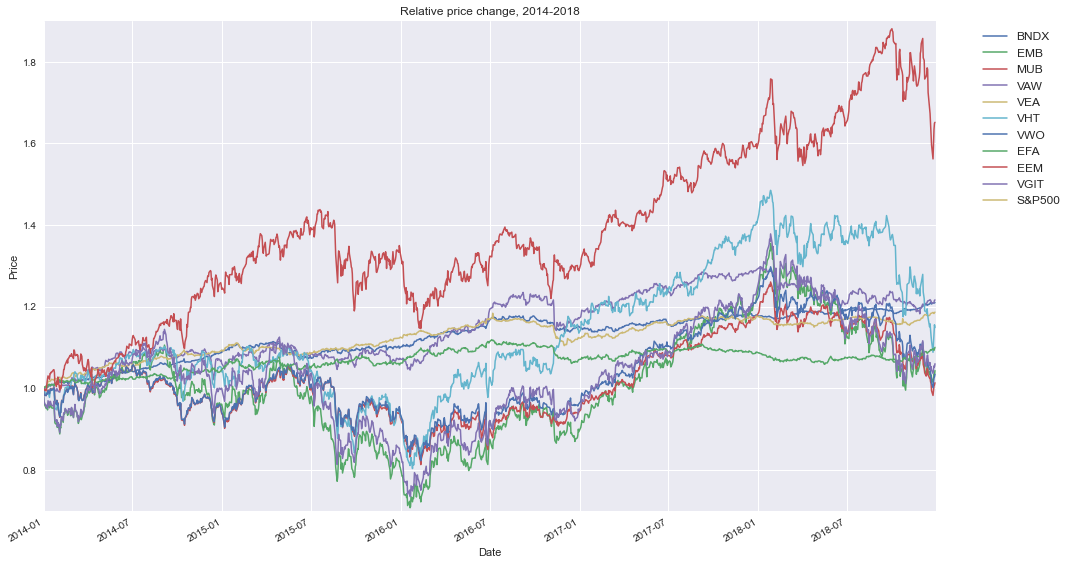

In [14]:
ax1 = (traindataset / traindataset.iloc[0,:]).plot()
(spdr_data1 / spdr_data1.iloc[1:2]).plot(ax=ax1)
ax1.set_xlim([datetime.date(2014, 1, 1), datetime.date(2018, 12, 31)])
ax1.set_ylim([0.7, 1.9])
ax1.set_ylabel("Price")
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.title('Relative price change, 2014-2018')


Text(0.5, 1.0, 'Relative price change, 2019')

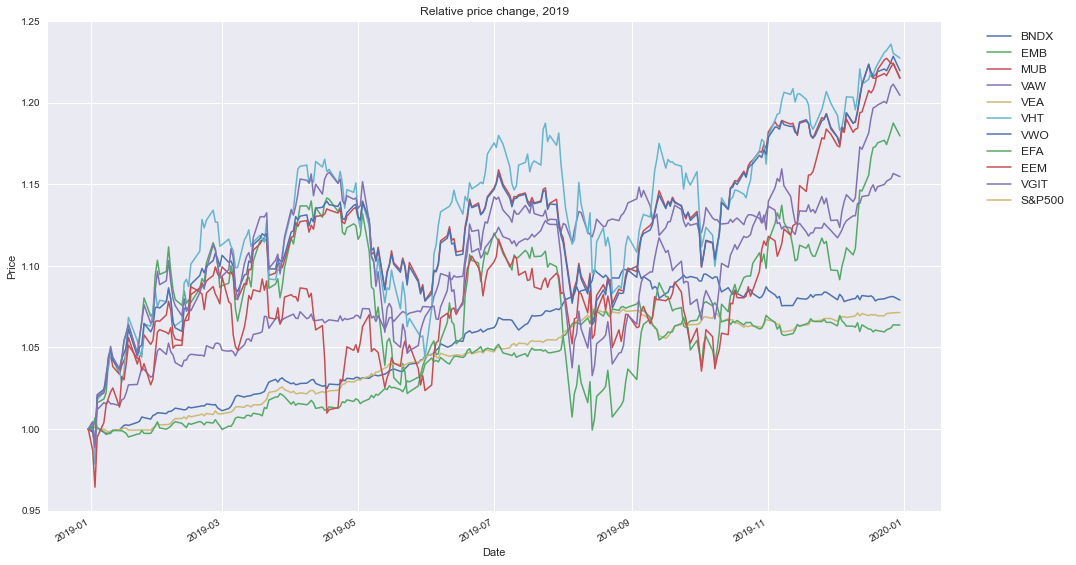

In [20]:
ax2 = (testdataset1 / testdataset1.iloc[0,:]).plot()
(spdr_data2 / spdr_data2.iloc[1:2]).plot(ax=ax2)
ax2.set_ylim([0.95, 1.25])
ax2.set_ylabel("Price")
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.title('Relative price change, 2019')


Text(0.5, 1.0, 'Relative price change, 2019-2021')

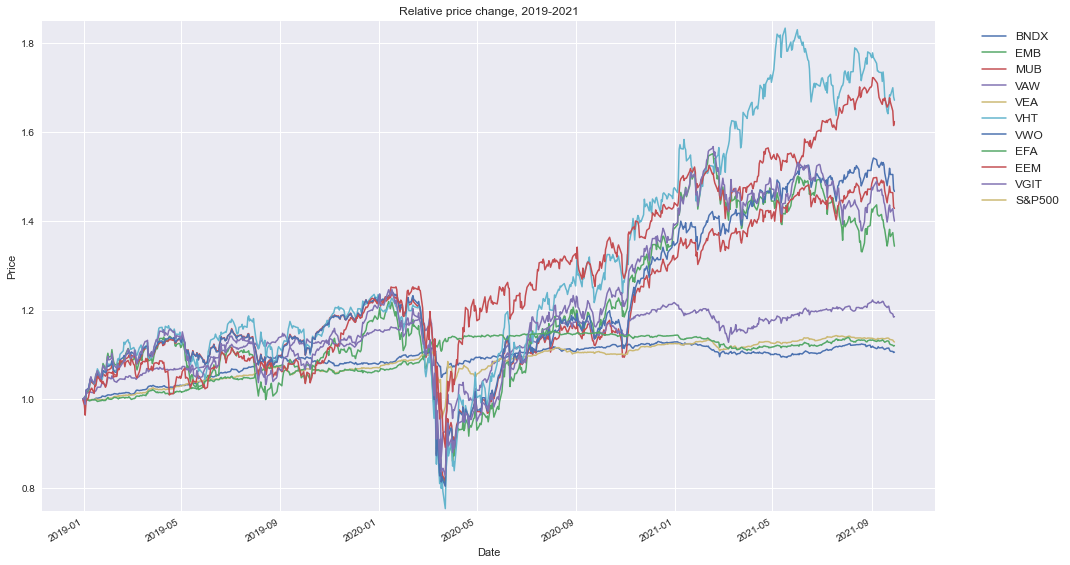

In [24]:
ax3 = (testdataset2 / testdataset2.iloc[0,:]).plot()
(spdr_data3 / spdr_data3.iloc[1:2]).plot(ax=ax3)
ax3.set_ylim([0.75, 1.85])
ax3.set_ylabel("Price")
plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.title('Relative price change, 2019-2021')

<a id='2.3'></a>
#### 3.3.Data Storage

In [ ]:
# Saving dataset as csv files

In [124]:
traindataset.to_csv("etfs_train.csv", header = etfs)

In [ ]:
testdataset1.to_csv("etfs_test_withoutcovid.csv", header = etfs)

In [ ]:
traindataset2.to_csv("etfs_test_withcovid.csv", header = etfs)

<a id='3'></a>
### 4. Designing RL Model

<p style='text-align: justify;'>Deep Q-Network(DQN) RL approach is applied for determining the policy for optimal portfolio allocation among a set of preselected ETFs. Depending on the current state of the portfolio, the algorithm performs the most beneficial action. </p>

<a id='3.1'></a>
#### 4.1. Creating RL environment

   <p style='text-align: justify;'> 
RL Framework is determined as follows:
 
* Agent: The representation of the portfolio manager.
    
* Environment: The representation of the trading environment.
    
* State: The state is defined as correlation matrix of the preselected ETFs based on a specific time window. Since the correlation matrix provides information about the relations between financial tools, it is a suitable to be selected as the state variable and can be useful in performing portfolio allocation.
    
* Action: In the proposed RL framework action is the portfolio weight assignment and rebalancing. The weights are converted from the Q-Values provided by DQN.
    
* Reward: The reward is defined as the portfolio Sharpe ratio, which consists of the standard deviation as the risk assessment measure, as it describes the excess return for the volatility of holding a riskier asset
   </p>



##### Defining the portfolio function

In [63]:
def Portfolio(returns, weights):
    weights = np.array(weights)
    returns_list = returns.mean() * 252
    covs = returns.cov() * 252
    P_ret = np.sum(returns_list * weights)
    P_vol = np.sqrt(np.dot(weights.T, np.dot(covs, weights)))
    P_sharpe = P_ret / P_vol
    return np.array([P_ret, P_vol, P_sharpe])

##### Creating RL Environment

 <p style='text-align: justify;'> The simulation of the trading environment is the RLEnvironment class that contains following key functions:

* Portfolio function. In RL Environment the arguments of Portfolio function are weights and returns in order to define key portfolio metrics. 

* Load data function. First the daily adjusted close prices of preselcted ETF are loaded and column with dates is dropped since for Agent in the environment new price is considered as next step. Moreover the hypothetical investment of 100000 is considered to be distributed among assets.
    
* Get state function. The arguments for this function are state which is represented by the correlation matrix depicting relations between ETFs based on a lookback period. In other words, the function generates the states applying the price data, timestep t and window size as  the number of days to be considered to evaluate the state by going back in time. As  the result, depending on booleans is_cov_matrix, is_raw_time_series, the fucntion returns the historical return or raw historical data respectively.
    
* Get reward function. The arguments for this function are action based rewards with α being the learning rate that represents the aggressiveness level to be applied to updating.The action is the weight of the portfolio. The local portfolio function is calculated analogically to previously described Portfolio function, however daily returns are calculated instead of annualised mean returns in order to be able to calculate reward at each timestep t. The rewards is calculated as portfolio Sharpe ratio based on the portfolio weight and lookback period. 
  </p>

In [64]:
 class RLEnvironment:
        
    def __init__(self, prices = 'etfs_train.csv', investment = 100000):       
        self.prices = prices  
        self.investment = investment  
        self.data = self.load_data()
        

    def load_data(self):
        data =  pd.read_csv(self.prices)
        try:
            data.index = data['Date']
            data = data.drop(columns = ['Date'])
        except:
            data.index = data['date']
            data = data.drop(columns = ['date'])            
        return data

    def preprocess_state(self, state):
        return state

    def get_state(self, t, lookback, is_cov_matrix = True, is_raw_time_series = False):

        assert lookback <= t

        decision_making_state = self.data.iloc[t-lookback:t]
        decision_making_state = decision_making_state.pct_change().dropna()
       
        if is_cov_matrix:
            x = decision_making_state.cov()
            return x
        else:
            if is_raw_time_series:
                decision_making_state = self.data.iloc[t-lookback:t]
            return self.preprocess_state(decision_making_state)
        
    def get_reward(self, action, action_t, reward_t, alpha = 0.01):

        def local_portfolio(returns, weights):
            weights = np.array(weights)
            returns_list = returns.mean() #* 252
            covs = returns.cov() #* 252
            P_ret = np.sum(returns_list * weights)
            P_vol = np.sqrt(np.dot(weights.T, np.dot(covs, weights)))
            P_sharpe = P_ret / P_vol
            return np.array([P_ret, P_vol, P_sharpe])

        data_period = self.data[action_t:reward_t]
        weights = action
        returns = data_period.pct_change().dropna()

        sharpe = local_portfolio(returns, weights)[-1]
        sharpe = np.array([sharpe] * len(self.data.columns))          
        rew = (data_period.values[-1] - data_period.values[0]) / data_period.values[0]

        return np.dot(returns, weights), sharpe
        

<a id='3.2'></a>
#### 4.2. Agent Script

 <p style='text-align: justify;'> DQNAgent class is created for performing Q-Learning using Deep Q-Network for converting output into weights of portfolio and vice versa. Boolean allow_short considers if the short positions are allowed, boolean is_eval is the switch for training and testing. For experience replay the memory buffer is created in order to store the historical data of the state, action, reward and next state transitions experienced by the RL Agent in one large exprerience replay memory as shown in image below (Hariom Tatsat et al. (2020))
    
*	Agent class function arguments: the batch size, state size and evaluation Boolean to switch between training and testing mode
*	Replay function adds, samples, and evaluates experience buffer
*	After each new state, new experience is stored in the replay buffer memory
*	Randomly sampled batch of experienced tuples from the memory are fed to the RL Model to learn and reduce overfitting at the same time
*	Current size of the buffer memory is returned
*	Number of actions ais 3: hold, buy, sell
*   The replay memory receives the batch of experience observations as input, loops across all of the observations in this mini-batch, and updates the weights of the DQN model, ensuring minimization of the MSE loss function. As the result of looping through mini-batch, only one update will be applied, whereas the update is happening in accordance with the determined earlier learning rate α and ADAM optimizer. 
*   The target variable is updated using formula based on Bellman Equation
*   The update is made at the state of termination or at the end of episode, which is the number of times the algorithm is trained through the entire data. For determining the end of episode or getting into termination point, the boolean variable done is used
*   DQN model makes prediction of the Q-Value for the next state and the current Q-value of this state for the action in the current replay buffer is set to the target, which is made for updating the model weights by applying model.fit function.
*   In order to learn the Neural Network parameters, DQN applies gradient descent to a loss function
  </p>

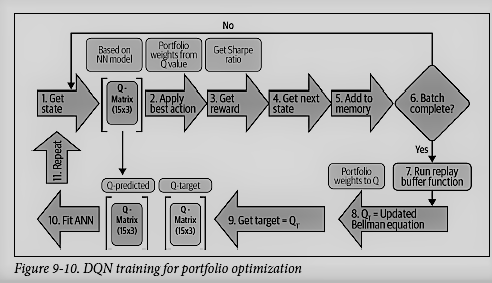

In [1]:
#Import library
from IPython.display import Image
# Load image from local storage
Image(filename = "13.png", width = 600, height = 300)

In [65]:
class DQNAgent:
    
    def __init__(
                     self, 
                     portfolio_size,
                     is_eval = False, 
                     allow_short = True,
                     
        
                 ):
        
        self.portfolio_size = portfolio_size
        self.allow_short = allow_short
        self.input_shape = (portfolio_size, portfolio_size, )
        self.action_size = 3 # hold, buy, sell
 
        self.experiencereplay = []
        self.is_eval = is_eval

        self.alpha = 0.1
        self.gamma = 0.9
        self.epsilon = 0.85
        self.epsilon_min = 0.1
        self.epsilon_decay = 0.9
        
        self.model = self._model()
 

    def _model(self):
        
 
        inputs = Input(shape=self.input_shape)        
        x = Flatten()(inputs)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.3)(x)
        x = Dense(32, activation='relu')(x)
        x = Dropout(0.3)(x)
        x = Dense(8, activation='relu')(x)
        x = Dropout(0.3)(x)
        
        predictions = []
        for i in range(self.portfolio_size):
            asset_dense = Dense(self.action_size, activation='linear')(x)   
            predictions.append(asset_dense)
        
        model = Model(inputs=inputs, outputs=predictions)
        model.compile(optimizer='adam', loss='mse')
        
        return model

    def nn_pred_to_weights(self, pred, allow_short = True):

        weights = np.zeros(len(pred))  #returns a new array of given shape and type, where the element's value as 0
        raw_weights = np.argmax(pred, axis=-1)  #returns the indices of the maximum values along an axis

        saved_min = None
        
        for e, r in enumerate(raw_weights):
            if r == 0: # hold
                weights[e] = 0
            elif r == 1: # buy
                weights[e] = np.abs(pred[e][0][r])
            else:
                weights[e] = -np.abs(pred[e][0][r])
        #sum of absolute values if short is allowed
        if not allow_short:
            weights += np.abs(np.min(weights))
            saved_min = np.abs(np.min(weights))
            saved_sum = np.sum(weights)
        else:
            saved_sum = np.sum(np.abs(weights))
            
        weights /= saved_sum
        return weights, saved_min, saved_sum
    #return the action based on the state, uses the NN function 
    def act(self, state):
        
        if not self.is_eval and random.random() <= self.epsilon:
            w = np.random.normal(0, 1, size = (self.portfolio_size, ))  
              
            saved_min = None
            
            if not self.allow_short:
                w += np.abs(np.min(w))
                saved_min = np.abs(np.min(w))
                
            saved_sum = np.sum(w)
            w /= saved_sum
            return w , saved_min, saved_sum

        pred = self.model.predict(np.expand_dims(state.values, 0))
        return self.nn_pred_to_weights(pred, self.allow_short)

    def expReplay(self, batch_size):

        def weights_to_nn_preds_with_reward(action_weights, reward, Q_star = np.zeros((self.portfolio_size, self.action_size))): 
            
            Q = np.zeros((self.portfolio_size, self.action_size))           
            for i in range(self.portfolio_size):
                if action_weights[i] == 0:
                    Q[i][0] = reward[i] + self.gamma * np.max(Q_star[i][0])
                elif action_weights[i] > 0:
                    Q[i][1] = reward[i] + self.gamma * np.max(Q_star[i][1])
                else:
                    Q[i][2] = reward[i] + self.gamma * np.max(Q_star[i][2])            
            return Q  
        
        def restore_Q_from_weights_and_stats(action):            
            action_weights, action_min, action_sum = action[0], action[1], action[2]
            action_weights = action_weights * action_sum          
            if action_min != None:
                action_weights = action_weights - action_min   
            return action_weights
        
        for (s, s_, action, reward, done) in self.experiencereplay:
            
            action_weights = restore_Q_from_weights_and_stats(action) 
            #Reward = reward if not in the terminal state. 
            Q_learned_value = weights_to_nn_preds_with_reward(action_weights, reward)
            s, s_ = s.values, s_.values    

            if not done:
                # reward + gamma * Q^*(s_, a_)
                Q_star = self.model.predict(np.expand_dims(s_, 0))
                Q_learned_value = weights_to_nn_preds_with_reward(action_weights, reward, np.squeeze(Q_star))  

            Q_learned_value = [xi.reshape(1, -1) for xi in Q_learned_value]
            Q_current_value = self.model.predict(np.expand_dims(s, 0))
            Q = [np.add(a * (1-self.alpha), q * self.alpha) for a, q in zip(Q_current_value, Q_learned_value)]
            
            # update current Q function with new optimal value
            self.model.fit(np.expand_dims(s, 0), Q, epochs=1, verbose=0)            
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay 

<a id='3.3'></a>
#### 4.3. Model Training

 <p style='text-align: justify;'> In this section, the algorithms is calling Agent to train in RL Environment.
    
* Episode is the number of times the code is trained through the entire data. 
* Windows size is the number of days to consider to evaluate the state.
* Batch size is the size of the replay buffer or memory use during training.
* Rebalance period is the period of time after which portfolio weights are rebalanced. RL Agent rebalances weights by reallocating the hypothetical investment of 100.000 among financial assets
    
  </p>

In [66]:
N_ASSETS = len(traindataset.columns)
agent = DQNAgent(N_ASSETS)
env = RLEnvironment()

In [67]:
window_size = 126 # half-year period is considered to evaluate the state
episode_count = 50
batch_size = 64
rebalance_period = 63 #every quarter weights change

In [68]:
data_length = len(env.data)
data_length

1259

In [69]:
np.random.randint(window_size+1, (data_length-window_size-1))

925

Episode 0/50 epsilon 0.5576850000000001


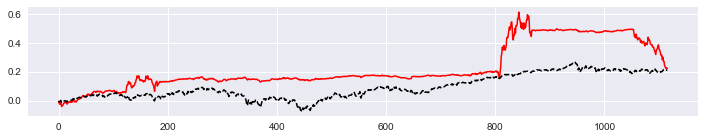

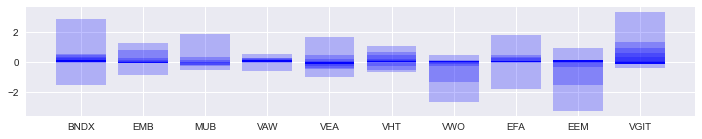

Episode 1/50 epsilon 0.5019165000000001


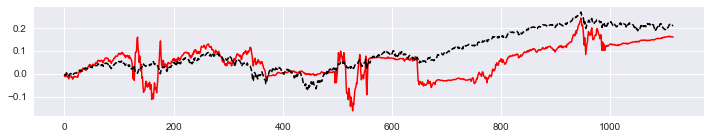

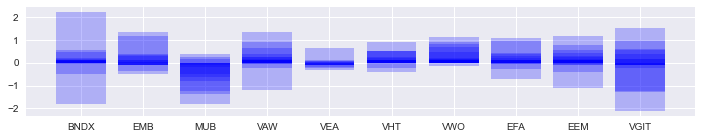

Episode 2/50 epsilon 0.5019165000000001


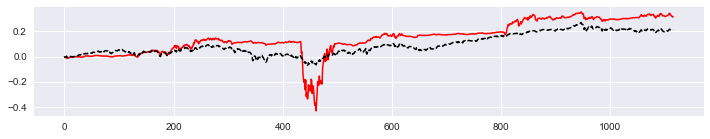

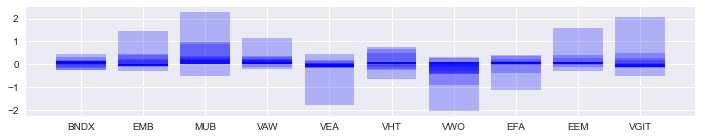

Episode 3/50 epsilon 0.5019165000000001


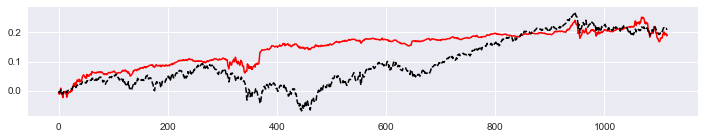

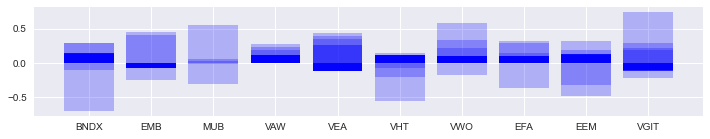

Episode 4/50 epsilon 0.4517248500000001


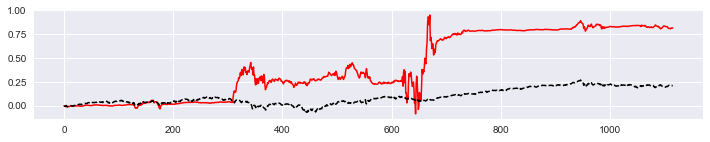

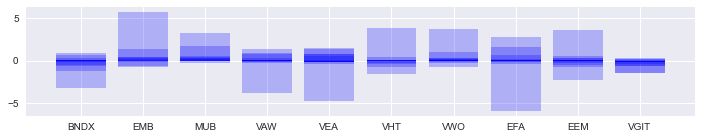

Episode 5/50 epsilon 0.4517248500000001


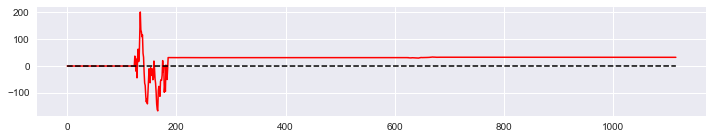

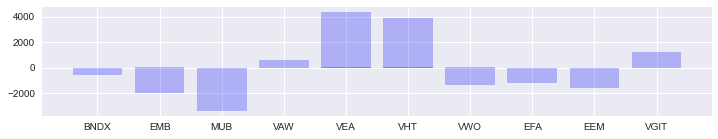

Episode 6/50 epsilon 0.4517248500000001


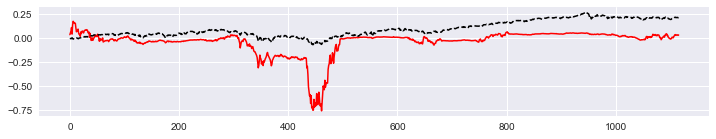

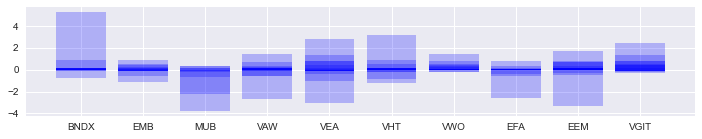

Episode 7/50 epsilon 0.4517248500000001


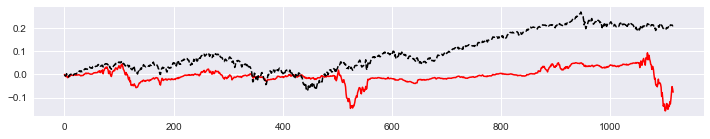

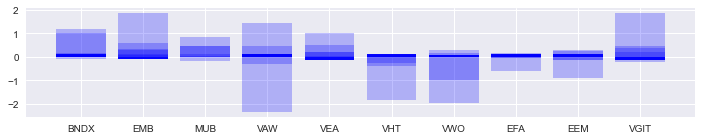

Episode 8/50 epsilon 0.40655236500000014


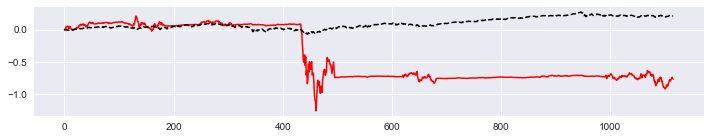

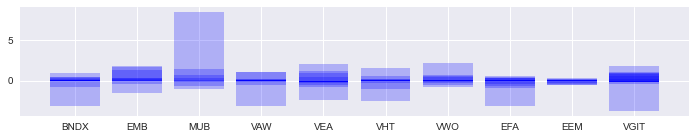

Episode 9/50 epsilon 0.40655236500000014


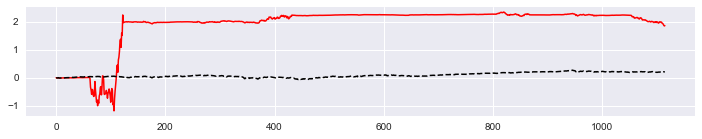

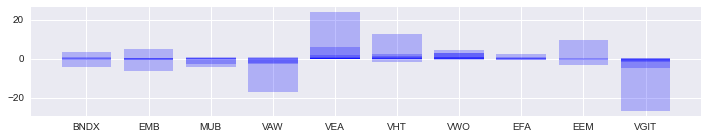

Episode 10/50 epsilon 0.40655236500000014


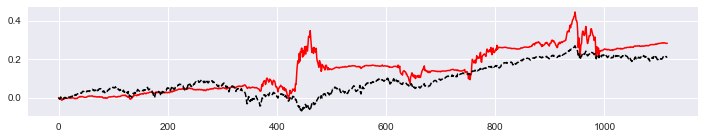

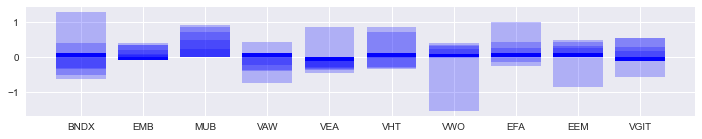

Episode 11/50 epsilon 0.3658971285000001


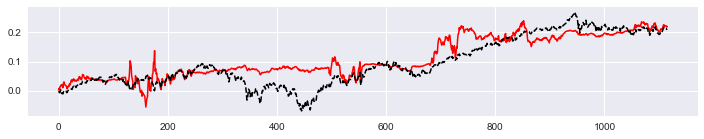

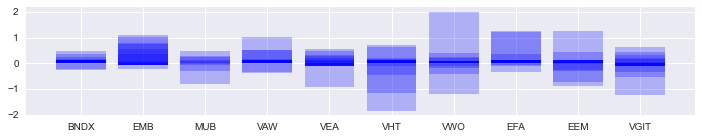

Episode 12/50 epsilon 0.3658971285000001


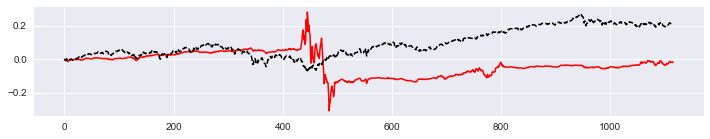

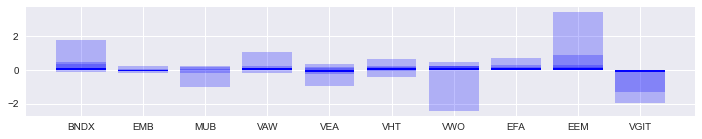

Episode 13/50 epsilon 0.3658971285000001


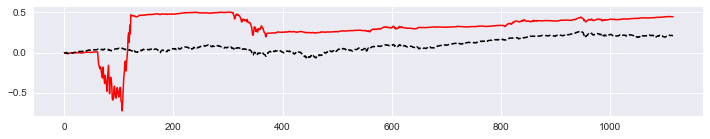

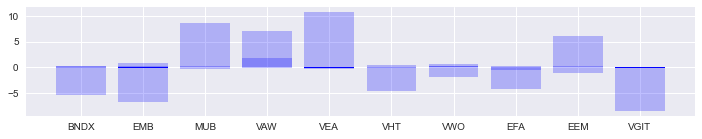

Episode 14/50 epsilon 0.3658971285000001


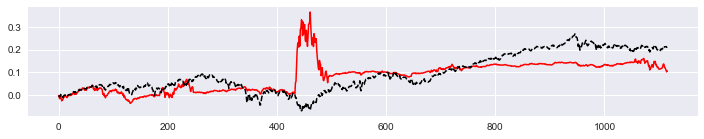

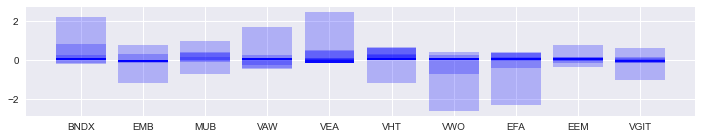

Episode 15/50 epsilon 0.3293074156500001


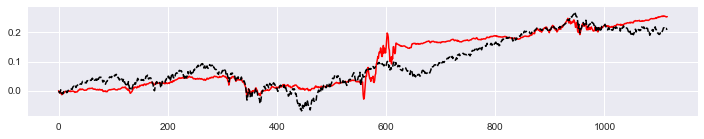

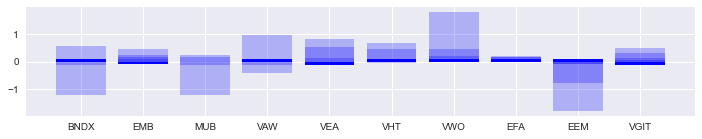

Episode 16/50 epsilon 0.3293074156500001


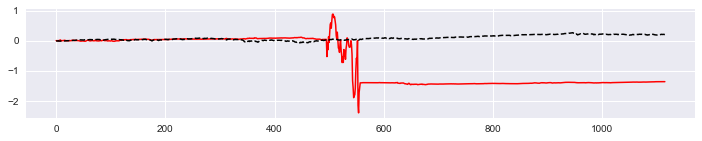

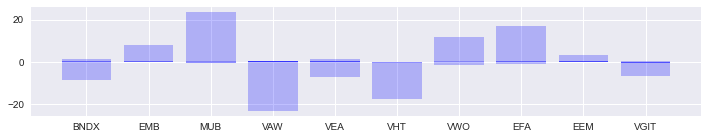

Episode 17/50 epsilon 0.3293074156500001


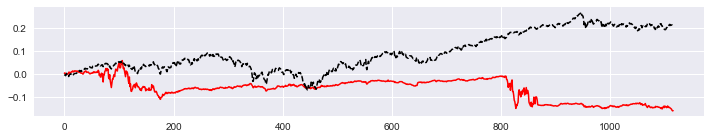

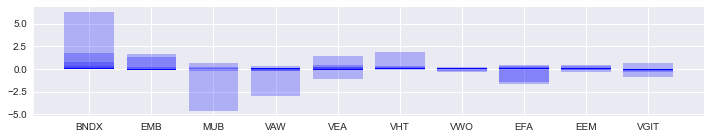

Episode 18/50 epsilon 0.2963766740850001


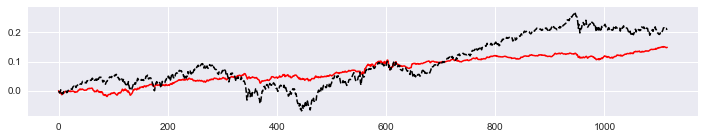

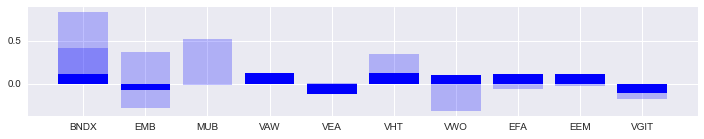

Episode 19/50 epsilon 0.2963766740850001


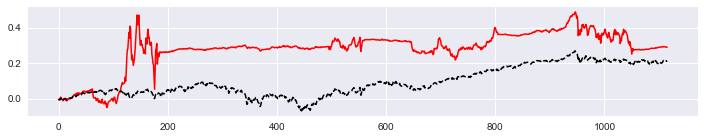

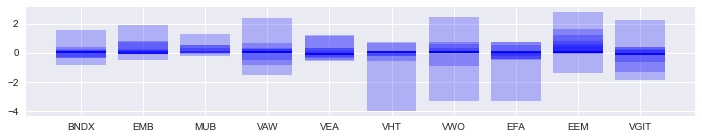

Episode 20/50 epsilon 0.2963766740850001


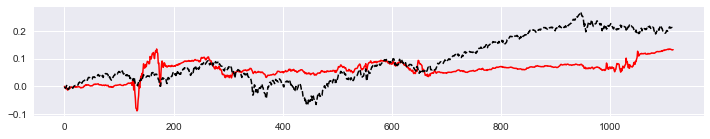

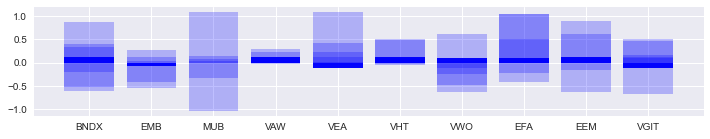

Episode 21/50 epsilon 0.2963766740850001


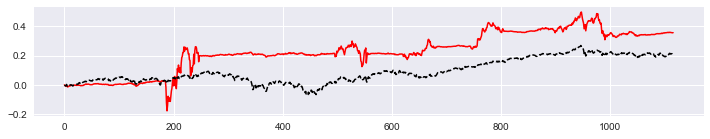

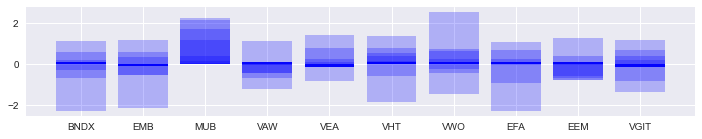

Episode 22/50 epsilon 0.26673900667650013


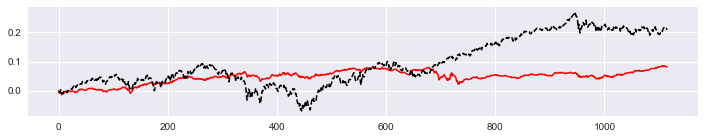

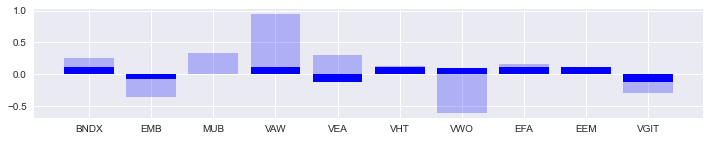

Episode 23/50 epsilon 0.26673900667650013


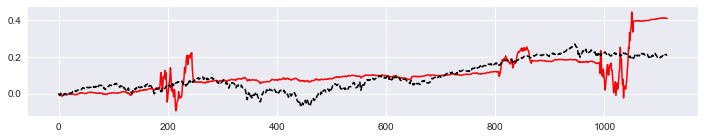

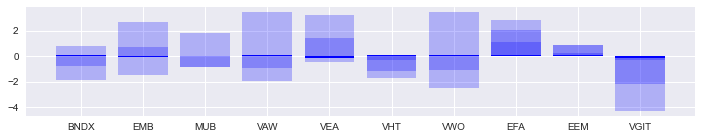

Episode 24/50 epsilon 0.26673900667650013


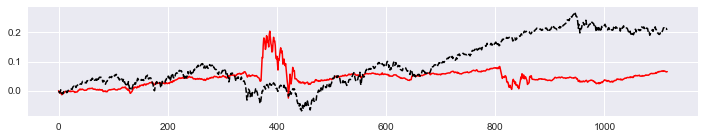

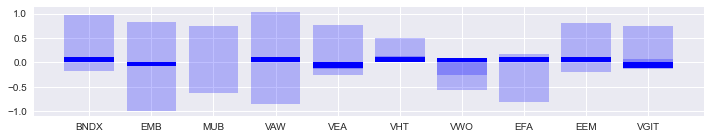

Episode 25/50 epsilon 0.24006510600885012


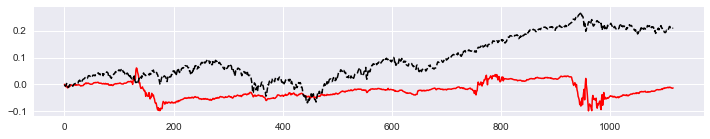

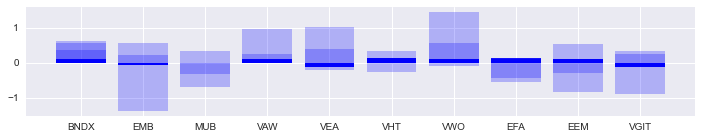

Episode 26/50 epsilon 0.24006510600885012


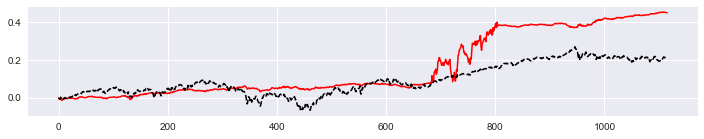

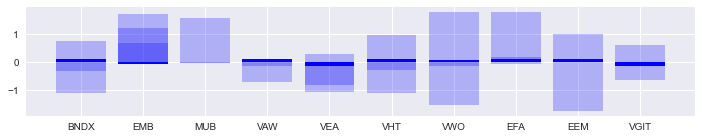

Episode 27/50 epsilon 0.24006510600885012


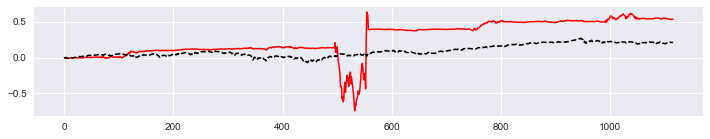

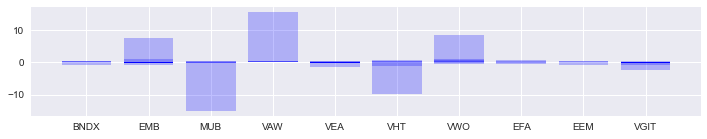

Episode 28/50 epsilon 0.24006510600885012


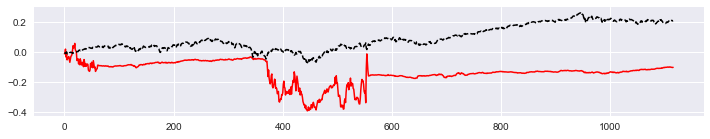

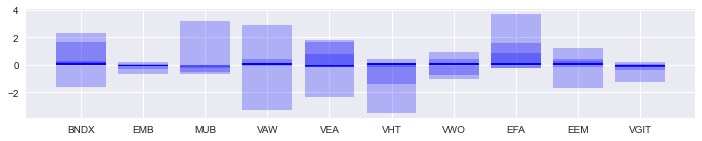

Episode 29/50 epsilon 0.2160585954079651


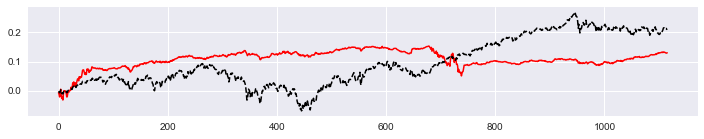

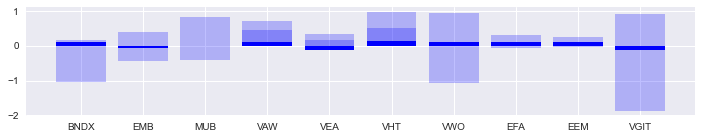

Episode 30/50 epsilon 0.2160585954079651


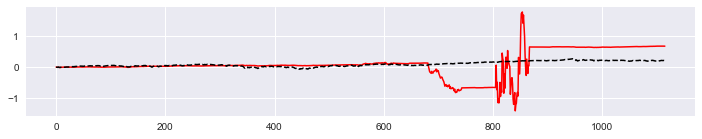

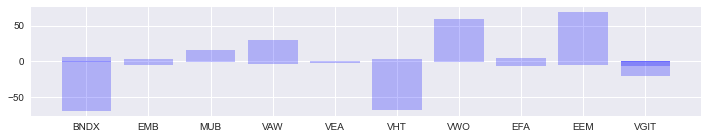

Episode 31/50 epsilon 0.2160585954079651


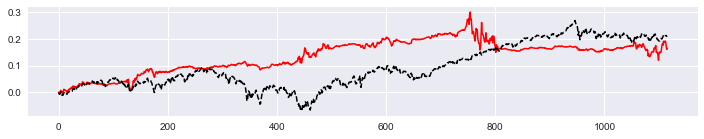

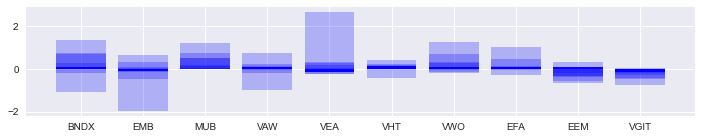

Episode 32/50 epsilon 0.2160585954079651


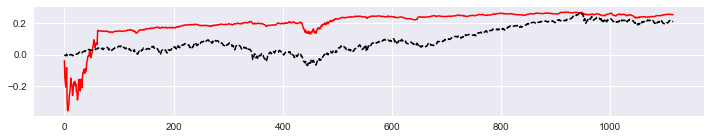

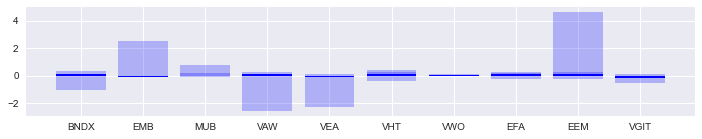

Episode 33/50 epsilon 0.1944527358671686


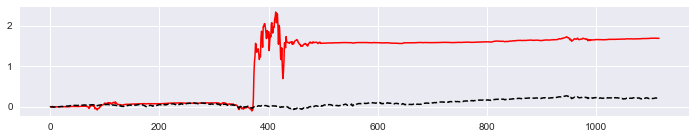

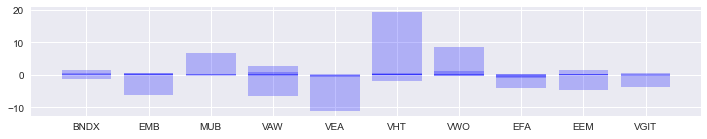

Episode 34/50 epsilon 0.1944527358671686


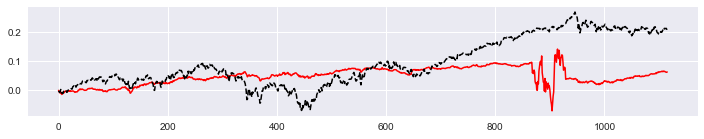

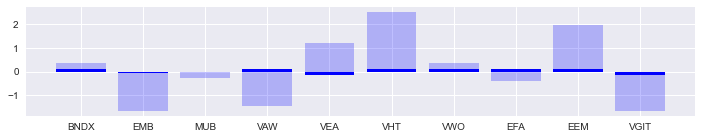

Episode 35/50 epsilon 0.1944527358671686


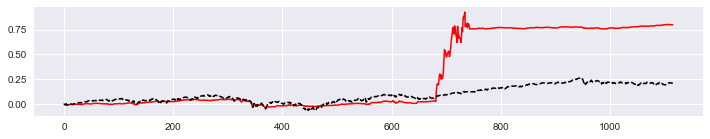

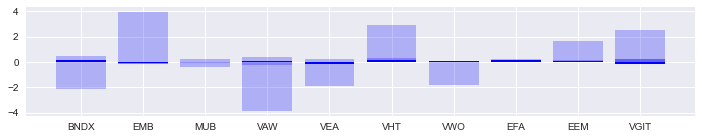

Episode 36/50 epsilon 0.17500746228045175


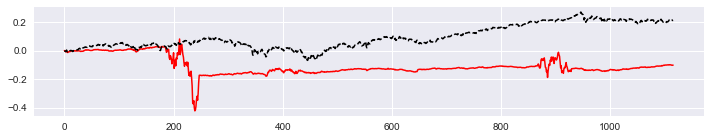

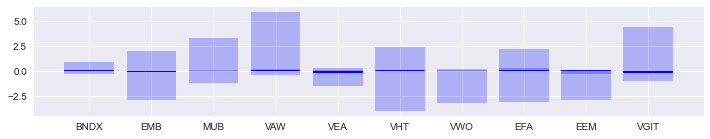

Episode 37/50 epsilon 0.17500746228045175


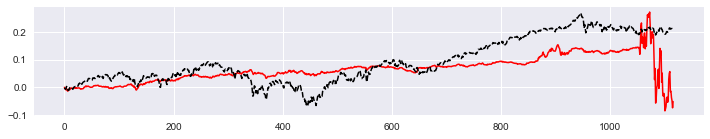

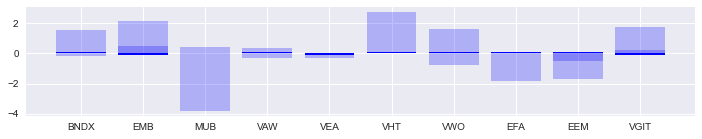

Episode 38/50 epsilon 0.17500746228045175


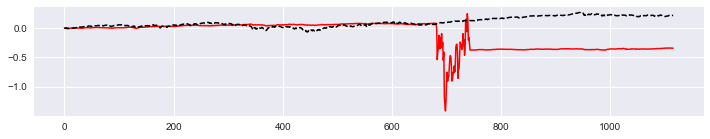

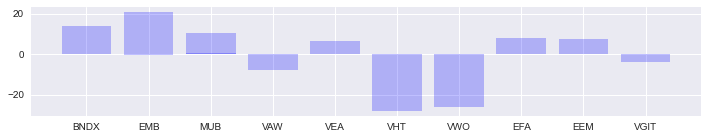

Episode 39/50 epsilon 0.17500746228045175


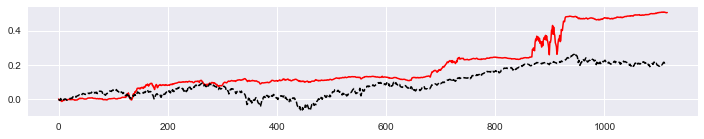

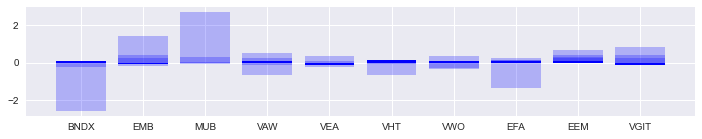

Episode 40/50 epsilon 0.15750671605240657


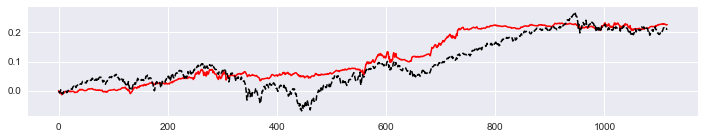

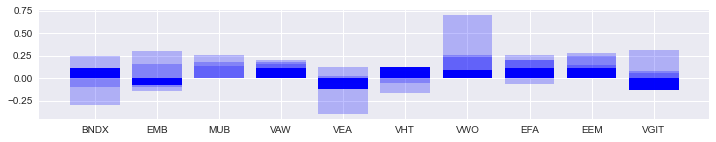

Episode 41/50 epsilon 0.15750671605240657


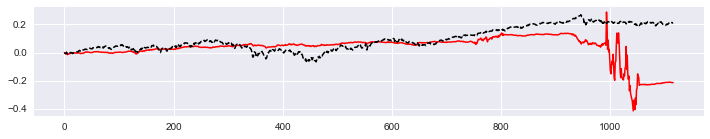

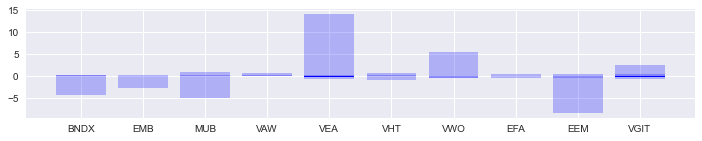

Episode 42/50 epsilon 0.15750671605240657


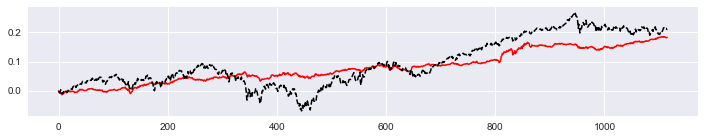

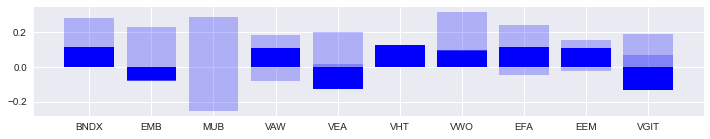

Episode 43/50 epsilon 0.1417560444471659


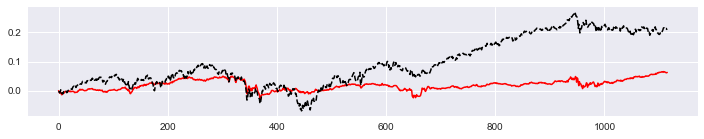

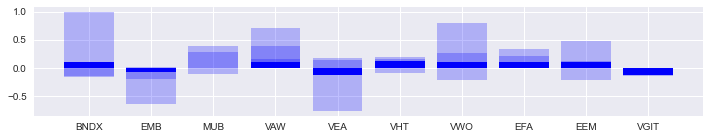

Episode 44/50 epsilon 0.1417560444471659


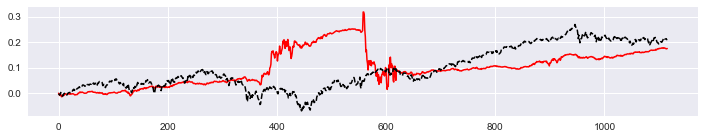

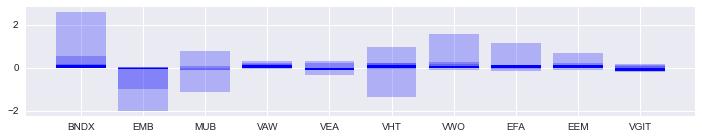

Episode 45/50 epsilon 0.1417560444471659


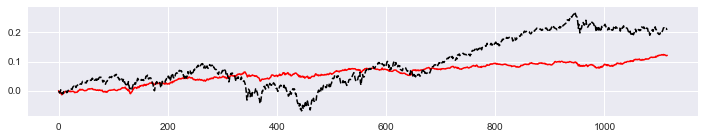

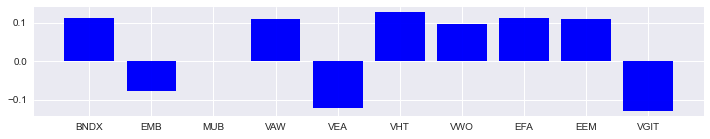

Episode 46/50 epsilon 0.1417560444471659


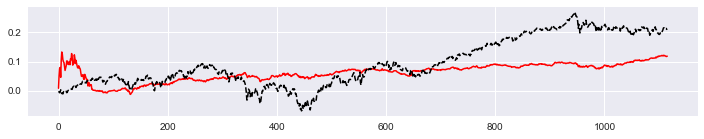

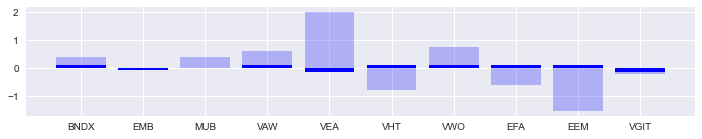

Episode 47/50 epsilon 0.12758044000244934


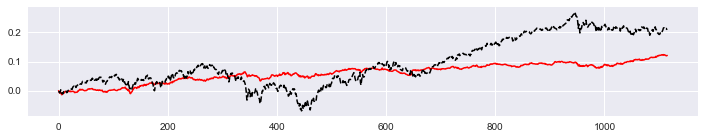

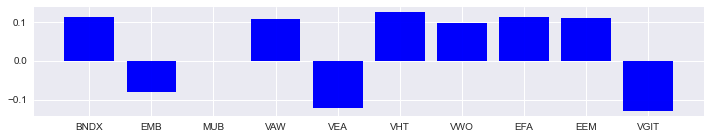

Episode 48/50 epsilon 0.12758044000244934


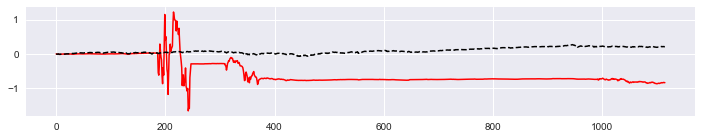

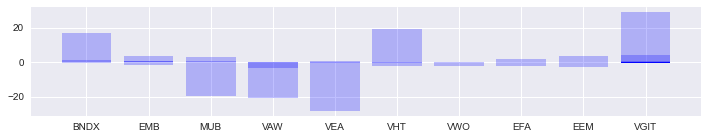

Episode 49/50 epsilon 0.12758044000244934


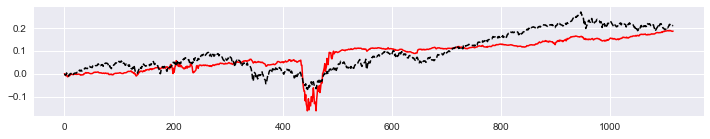

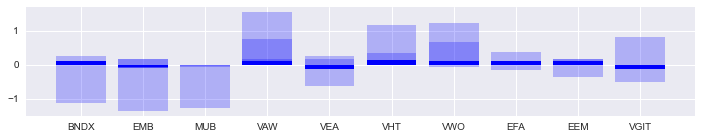

In [72]:
for e in range(episode_count):
    
    agent.is_eval = False
    data_length = len(env.data)
    
    
    returns_history = []
    returns_history_equal = []
    
    rewards_history = []
    equal_rewards = []
    
    actions_to_show = []
    
    print("Episode " + str(e) + "/" + str(episode_count), 'epsilon', agent.epsilon)

    s = env.get_state(np.random.randint(window_size+1, data_length-window_size-1), window_size)
    total_profit = 0 

    for t in range(window_size, data_length, rebalance_period):
        date1 = t-rebalance_period
        #correlation from quarter to half-year
        s_ = env.get_state(t, window_size)
        action = agent.act(s_)
        
        actions_to_show.append(action[0])
        
        weighted_returns, reward = env.get_reward(action[0], date1, t)
        weighted_returns_equal, reward_equal = env.get_reward(
            np.ones(agent.portfolio_size) / agent.portfolio_size, date1, t)

        rewards_history.append(reward)
        equal_rewards.append(reward_equal)
        returns_history.extend(weighted_returns)
        returns_history_equal.extend(weighted_returns_equal)

        done = True if t == data_length else False
        agent.experiencereplay.append((s, s_, action, reward, done))
        
        if len(agent.experiencereplay) >= batch_size:
            agent.expReplay(batch_size)
            agent.experiencereplay = []
            
        s = s_

    rl_result = np.array(returns_history).cumsum()
    equal_result = np.array(returns_history_equal).cumsum()

    plt.figure(figsize = (12, 2))
    plt.plot(rl_result, color = 'red', ls = '-')
    plt.plot(equal_result, color = 'black', ls = '--')
    plt.show()
    
    plt.figure(figsize = (12, 2))
    for a in actions_to_show:    
        plt.bar(np.arange(N_ASSETS), a, color = 'blue', alpha = 0.25)
        plt.xticks(np.arange(N_ASSETS), env.data.columns, rotation='horizontal')
    plt.show()
    

<a id='4'></a>
### 5. Testing the Model

<p style='text-align: justify;'>The testing dataset is subdivided into the testing data for pre-COVID period of  2019, as well as for COVID period from 2019 until the end of September 2021. </p>

 <a id='4.1'></a>
#### 5.1. Testing excluding COVID Period 

In [98]:
datasettest1 = pd.read_csv('etfs_test_withoutcovid.csv',index_col=0)

In [99]:
env.data = datasettest1

In [100]:
len(env.data)

252

In [101]:
agent.is_eval = True

actions_equal, actions_rl = [], []
result_equal, result_rl = [], []

for t in range(window_size, len(env.data), rebalance_period):

    date1 = t-rebalance_period
    s_ = env.get_state(t, window_size)
    action = agent.act(s_)

    weighted_returns, reward = env.get_reward(action[0], date1, t)
    weighted_returns_equal, reward_equal = env.get_reward(
        np.ones(agent.portfolio_size) / agent.portfolio_size, date1, t)

    result_equal.append(weighted_returns_equal.tolist())
    actions_equal.append(np.ones(agent.portfolio_size) / agent.portfolio_size)
    
    result_rl.append(weighted_returns.tolist())
    actions_rl.append(action[0])

In [102]:
result_equal_vis = [item for sublist in result_equal for item in sublist]
result_rl_vis = [item for sublist in result_rl for item in sublist]

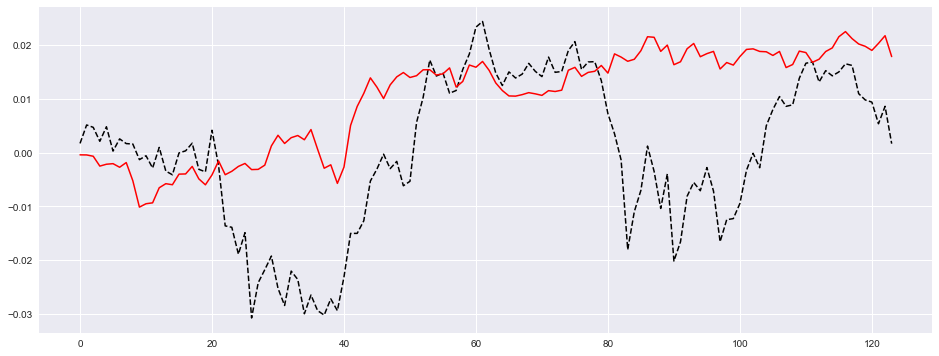

In [78]:
plt.figure(figsize = (16, 6))
plt.plot(np.array(result_equal_vis).cumsum(), label = 'Benchmark', color = 'black',ls = '--')
plt.plot(np.array(result_rl_vis).cumsum(), label = 'RL Portfolio', color = 'red',ls = '-')
plt.show()

In [105]:
import statsmodels.api as sm
from statsmodels import regression
def sharpe(R):
    r = np.diff(R)
    sr = r.mean()/r.std() * np.sqrt(252)
    return sr

def print_stats(result, benchmark):

    sharpe_ratio = sharpe(np.array(result).cumsum())
    returns = np.mean(np.array(result))
    volatility = np.std(np.array(result))
        
    X = benchmark
    y = result
    x = sm.add_constant(X)
    model = regression.linear_model.OLS(y, x).fit()    
    alpha = model.params[0]
    beta = model.params[1]
    
    return np.round(np.array([returns, volatility, sharpe_ratio, alpha, beta]), 4).tolist()

In [106]:
print('BENCHMARK', print_stats(result_equal_vis, result_equal_vis))
print('RL AGENT', print_stats(result_rl_vis, result_equal_vis))

BENCHMARK [0.0, 0.0048, -0.0012, 0.0, 1.0]
RL AGENT [0.0001, 0.0019, 1.2447, 0.0001, 0.1874]


 <a id='4.2'></a>
#### 5.2. Testing including COVID Period 


In [89]:
datasettest2 = pd.read_csv('etfs_test_withcovid.csv',index_col=0)

In [90]:
env.data = datasettest2

In [91]:
len(env.data)

692

In [92]:
agent.is_eval = True

actions_equal, actions_rl = [], []
result_equal, result_rl = [], []

for t in range(window_size, len(env.data), rebalance_period):

    date1 = t-rebalance_period
    s_ = env.get_state(t, window_size)
    action = agent.act(s_)

    weighted_returns, reward = env.get_reward(action[0], date1, t)
    weighted_returns_equal, reward_equal = env.get_reward(
        np.ones(agent.portfolio_size) / agent.portfolio_size, date1, t)

    result_equal.append(weighted_returns_equal.tolist())
    actions_equal.append(np.ones(agent.portfolio_size) / agent.portfolio_size)
    
    result_rl.append(weighted_returns.tolist())
    actions_rl.append(action[0])

In [93]:
result_equal_vis = [item for sublist in result_equal for item in sublist]
result_rl_vis = [item for sublist in result_rl for item in sublist]

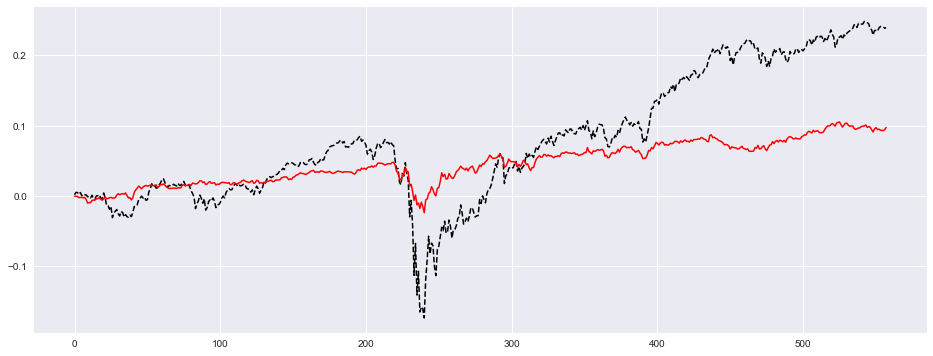

In [94]:
plt.figure(figsize = (16, 6))
plt.plot(np.array(result_equal_vis).cumsum(), label = 'Benchmark', color = 'black',ls = '--')
plt.plot(np.array(result_rl_vis).cumsum(), label = 'RL Portfolio', color = 'red',ls = '-')
plt.show()

In [95]:
import statsmodels.api as sm
from statsmodels import regression
def sharpe(R):
    r = np.diff(R)
    sr = r.mean()/r.std() * np.sqrt(252)
    return sr

def print_stats(result, benchmark):

    sharpe_ratio = sharpe(np.array(result).cumsum())
    returns = np.mean(np.array(result))
    volatility = np.std(np.array(result))
    
    X = benchmark
    y = result
    x = sm.add_constant(X)
    model = regression.linear_model.OLS(y, x).fit()    
    alpha = model.params[0]
    beta = model.params[1]
    
    return np.round(np.array([returns, volatility, sharpe_ratio, alpha, beta]), 4).tolist()

In [96]:
print('BENCHMARK', print_stats(result_equal_vis, result_equal_vis))
print('RL AGENT', print_stats(result_rl_vis, result_equal_vis))

BENCHMARK [0.0004, 0.0096, 0.7061, 0.0, 1.0]
RL AGENT [0.0002, 0.0031, 0.8866, 0.0001, 0.2234]


<p style='text-align: justify;'> For pre-COVID period, the RL portfolio has a slightly higher return with much higher Sharp ratio, considerably lower portfolio volatility, slightly higher alpha and much lower correlation with the benchmark of equally weighted portfolio. </p>

<p style='text-align: justify;'> For the time period that includes COVID period, the RL portfolio showed lower return with much higher Sharp ratio, considerably lower portfolio volatility, slightly higher alpha and much lower correlation with the benchmark of equally weighted portfolio, which means that while RL algorithm cannot recognize "Black Swan" events like COVID, it can smoother out the portfolio volatility.  </p>

**Conclusion**
<p style='text-align: justify;'>

In the frame of this thesis, inspired by recent work proposed by Hariom Tatsat et al. (2020), RL framework applied to tackle Portfolio Selection Problem beyond classical Markowitz efficient frontier approach and to develop the beneficial policy by dynamically changing the weights in the contstantly changing market. 

Overall, the aim of exploring the potential of integrating RL method to potfolio allocation problem was achieved and the RL application proved to be effecient. This entails that RL algorithms are immensely useful due to flexible and automated approach, especifically with potential application in Robo-Advising systems.
</p>